# SegTHOR exploratory data analysis

This notebook compares the original data with the cleaned data. The analysis covers CT intensity ranges and percentiles, voxel spacing and dimensions, label differences, physical organ volumes, and class imbalance across the 20 patients.

In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
summary = pd.read_csv('patient_comparison_summary.csv', index_col=0)

In [5]:
ORIGINAL_ROOT = Path('data/segthor_part1/train')
CLEAN_ROOT = Path('data/train')
CLASS_NAMES = {0: 'background', 1: 'esophagus', 2: 'heart', 3: 'trachea', 4: 'aorta'}
PERCENTILES = [1, 5, 25, 50, 75, 95, 99]

In [6]:
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 6)

if not ORIGINAL_ROOT.exists() or not CLEAN_ROOT.exists():
    raise FileNotFoundError(f'Expected {ORIGINAL_ROOT} and {CLEAN_ROOT} from the repository root.')

original_patients = {p.name for p in ORIGINAL_ROOT.glob('Patient_*') if p.is_dir()}
clean_patients = {p.name for p in CLEAN_ROOT.glob('Patient_*') if p.is_dir()}
patients = sorted(original_patients & clean_patients)

if original_patients != clean_patients:
    print('Warning: patient sets differ.')
    print('Only original:', sorted(original_patients - clean_patients))
    print('Only clean:', sorted(clean_patients - original_patients))

print(f'Patients compared: {len(patients)}')

Patients compared: 20


## Loading and summary helpers

CT values are read from the NIfTI files without normalization, so the intensity analysis is in the source CT intensity units, normally Hounsfield Units (HU) for SegTHOR. Label volumes are treated as integer class IDs.

In [9]:
def load_patient(root: Path, patient: str):
    patient_dir = root / patient
    ct_path = patient_dir / f'{patient}.nii.gz'
    gt_path = patient_dir / 'GT.nii.gz'
    if not ct_path.exists() or not gt_path.exists():
        raise FileNotFoundError(f'Missing CT or GT for {patient} under {root}')
    ct_img = nib.load(str(ct_path))
    gt_img = nib.load(str(gt_path))
    ct = np.asanyarray(ct_img.dataobj)
    gt = np.asanyarray(gt_img.dataobj).astype(np.int16)
    return ct_img, gt_img, ct, gt

In [ ]:
def describe_ct(ct):
    values = np.asarray(ct, dtype=np.float32)
    percentiles = np.percentile(values, PERCENTILES)
    result = {'min': float(values.min()), 'max': float(values.max())}
    result.update({f'p{p}': float(value) for p, value in zip(PERCENTILES, percentiles)})
    return result


def class_counts(gt):
    counts = np.bincount(gt.ravel(), minlength=len(CLASS_NAMES))
    return {f'class_{class_id}_voxels': int(counts[class_id]) for class_id in CLASS_NAMES}


def arrays_equal(a, b):
    return a.shape == b.shape and np.array_equal(a, b)


def compare_patient(patient):
    original_ct_img, original_gt_img, original_ct, original_gt = load_patient(ORIGINAL_ROOT, patient)
    clean_ct_img, clean_gt_img, clean_ct, clean_gt = load_patient(CLEAN_ROOT, patient)
    spacing = tuple(float(x) for x in original_ct_img.header.get_zooms()[:3])
    voxel_volume_mm3 = float(np.prod(spacing))
    
    row = {'patient': patient, 'shape_x': original_ct.shape[0], 'shape_y': original_ct.shape[1], 'shape_z': original_ct.shape[2],
           'spacing_x_mm': spacing[0], 'spacing_y_mm': spacing[1], 'spacing_z_mm': spacing[2],
           'voxel_volume_mm3': voxel_volume_mm3,
           'ct_arrays_equal': arrays_equal(original_ct, clean_ct),
           'ct_affines_equal': np.allclose(original_ct_img.affine, clean_ct_img.affine),
           'gt_arrays_equal': arrays_equal(original_gt, clean_gt),
           'gt_changed_voxels': int(np.count_nonzero(original_gt != clean_gt)) if original_gt.shape == clean_gt.shape else np.nan,
           'original_unique_labels': tuple(np.unique(original_gt).astype(int)),
           'clean_unique_labels': tuple(np.unique(clean_gt).astype(int))}
    
    row.update({f'original_{key}': value for key, value in describe_ct(original_ct).items()})
    row.update({f'clean_{key}': value for key, value in describe_ct(clean_ct).items()})
    row.update(class_counts(original_gt))
    row.update({f'clean_{key}': value for key, value in class_counts(clean_gt).items()})
    
    for class_id, class_name in CLASS_NAMES.items():
        row[f'original_{class_name}_volume_cm3'] = float((original_gt == class_id).sum() * voxel_volume_mm3 / 1000)
        row[f'clean_{class_name}_volume_cm3'] = float((clean_gt == class_id).sum() * voxel_volume_mm3 / 1000)
    
    return row

summary = pd.DataFrame([compare_patient(patient) for patient in patients]).set_index('patient')
summary.head()

,shape_x,shape_y,shape_z,spacing_x_mm,spacing_y_mm,spacing_z_mm,voxel_volume_mm3,ct_arrays_equal,ct_affines_equal,gt_arrays_equal,...,original_background_volume_cm3,clean_background_volume_cm3,original_esophagus_volume_cm3,clean_esophagus_volume_cm3,original_heart_volume_cm3,clean_heart_volume_cm3,original_trachea_volume_cm3,clean_trachea_volume_cm3,original_aorta_volume_cm3,clean_aorta_volume_cm3
patient,,,,,,,,,,,,,,,,,,,,,
Patient_01,512,512,229,0.976562,0.976562,2.0,1.907349,True,True,False,...,113476.566315,113476.566315,264.984131,61.750412,697.397232,697.397232,61.052322,61.052322,0.0,203.233719
Patient_02,512,512,246,0.976562,0.976562,2.5,2.384183,True,True,False,...,152607.334833,152607.334833,251.180880,46.257928,857.383368,857.383368,33.950773,33.950773,0.0,204.922953
Patient_03,512,512,147,0.976562,0.976562,2.5,2.384183,True,True,False,...,91279.858617,91279.858617,126.967306,32.193629,437.986423,437.986423,30.097932,30.097932,0.0,94.773677
Patient_04,512,512,158,0.976562,0.976562,2.5,2.384183,True,True,False,...,97508.554603,97508.554603,401.391591,43.978648,787.991708,787.991708,51.965663,51.965663,0.0,357.412943
Patient_05,512,512,284,0.976562,0.976562,2.0,1.907349,True,True,False,...,140778.738022,140778.738022,305.225372,44.771194,866.716385,866.716385,49.320221,49.320221,0.0,260.454178


In [7]:
summary.to_csv('patient_comparison_summary.csv', index=True)

In [8]:
summary.head(20)

,shape_x,shape_y,shape_z,spacing_x_mm,spacing_y_mm,spacing_z_mm,voxel_volume_mm3,ct_arrays_equal,ct_affines_equal,gt_arrays_equal,...,original_background_volume_cm3,clean_background_volume_cm3,original_esophagus_volume_cm3,clean_esophagus_volume_cm3,original_heart_volume_cm3,clean_heart_volume_cm3,original_trachea_volume_cm3,clean_trachea_volume_cm3,original_aorta_volume_cm3,clean_aorta_volume_cm3
patient,,,,,,,,,,,,,,,,,,,,,
Patient_01,512,512,229,0.976562,0.976562,2.0,1.907349,True,True,False,...,113476.566315,113476.566315,264.984131,61.750412,697.397232,697.397232,61.052322,61.052322,0.0,203.233719
Patient_02,512,512,246,0.976562,0.976562,2.5,2.384183,True,True,False,...,152607.334833,152607.334833,251.180880,46.257928,857.383368,857.383368,33.950773,33.950773,0.0,204.922953
Patient_03,512,512,147,0.976562,0.976562,2.5,2.384183,True,True,False,...,91279.858617,91279.858617,126.967306,32.193629,437.986423,437.986423,30.097932,30.097932,0.0,94.773677
Patient_04,512,512,158,0.976562,0.976562,2.5,2.384183,True,True,False,...,97508.554603,97508.554603,401.391591,43.978648,787.991708,787.991708,51.965663,51.965663,0.0,357.412943
Patient_05,512,512,284,0.976562,0.976562,2.0,1.907349,True,True,False,...,140778.738022,140778.738022,305.225372,44.771194,866.716385,866.716385,49.320221,49.320221,0.0,260.454178
Patient_06,512,512,199,0.976562,0.976562,2.5,2.384183,True,True,False,...,123101.939147,123101.939147,331.382428,45.444921,899.931506,899.931506,41.625459,41.625459,0.0,285.937507
Patient_07,512,512,179,0.976562,0.976562,2.0,1.907349,True,True,False,...,88554.208755,88554.208755,219.781876,48.248291,697.824478,697.824478,28.184891,28.184891,0.0,171.533585
Patient_08,512,512,171,0.976562,0.976562,2.5,2.384183,True,True,False,...,105989.109485,105989.109485,237.400300,35.824741,607.215765,607.215765,41.170080,41.170080,0.0,201.575559
Patient_09,512,512,154,0.976562,0.976562,2.5,2.384183,True,True,False,...,95140.709949,95140.709949,180.251422,38.351975,872.913939,872.913939,56.030696,56.030696,0.0,141.899447


## Cohort and file consistency

These checks test the central expectation: cleaning should change labels, not CT geometry or intensity data.

In [9]:
consistency_columns = ['shape_x', 'shape_y', 'shape_z', 'spacing_x_mm', 'spacing_y_mm', 'spacing_z_mm', 'ct_arrays_equal', 'ct_affines_equal']
display(summary[consistency_columns])
print('CT array differences:', int((~summary['ct_arrays_equal']).sum()))
print('CT affine differences:', int((~summary['ct_affines_equal']).sum()))
print('Patients with changed labels:', int((~summary['gt_arrays_equal']).sum()))
display(summary.loc[~summary['gt_arrays_equal'], ['gt_changed_voxels', 'original_unique_labels', 'clean_unique_labels']])

,shape_x,shape_y,shape_z,spacing_x_mm,spacing_y_mm,spacing_z_mm,ct_arrays_equal,ct_affines_equal
patient,,,,,,,,
Patient_01,512,512,229,0.976562,0.976562,2.0,True,True
Patient_02,512,512,246,0.976562,0.976562,2.5,True,True
Patient_03,512,512,147,0.976562,0.976562,2.5,True,True
Patient_04,512,512,158,0.976562,0.976562,2.5,True,True
Patient_05,512,512,284,0.976562,0.976562,2.0,True,True
Patient_06,512,512,199,0.976562,0.976562,2.5,True,True
Patient_07,512,512,179,0.976562,0.976562,2.0,True,True
Patient_08,512,512,171,0.976562,0.976562,2.5,True,True
Patient_09,512,512,154,0.976562,0.976562,2.5,True,True


CT array differences: 0
CT affine differences: 0
Patients with changed labels: 20


,gt_changed_voxels,original_unique_labels,clean_unique_labels
patient,,,
Patient_01,106553,"(0, 1, 2, 3)","(0, 1, 2, 3, 4)"
Patient_02,85951,"(0, 1, 2, 3)","(0, 1, 2, 3, 4)"
Patient_03,39751,"(0, 1, 2, 3)","(0, 1, 2, 3, 4)"
Patient_04,149910,"(0, 1, 2, 3)","(0, 1, 2, 3, 4)"
Patient_05,136553,"(0, 1, 2, 3)","(0, 1, 2, 3, 4)"
Patient_06,119931,"(0, 1, 2, 3)","(0, 1, 2, 3, 4)"
Patient_07,89933,"(0, 1, 2, 3)","(0, 1, 2, 3, 4)"
Patient_08,84547,"(0, 1, 2, 3)","(0, 1, 2, 3, 4)"
Patient_09,59517,"(0, 1, 2, 3)","(0, 1, 2, 3, 4)"


## HU histograms per patient

The first plot compares the original and clean CT arrays for each patient. If cleaning only changes labels, the paired curves should overlap exactly. The second plot shows cohort-level percentile summaries.

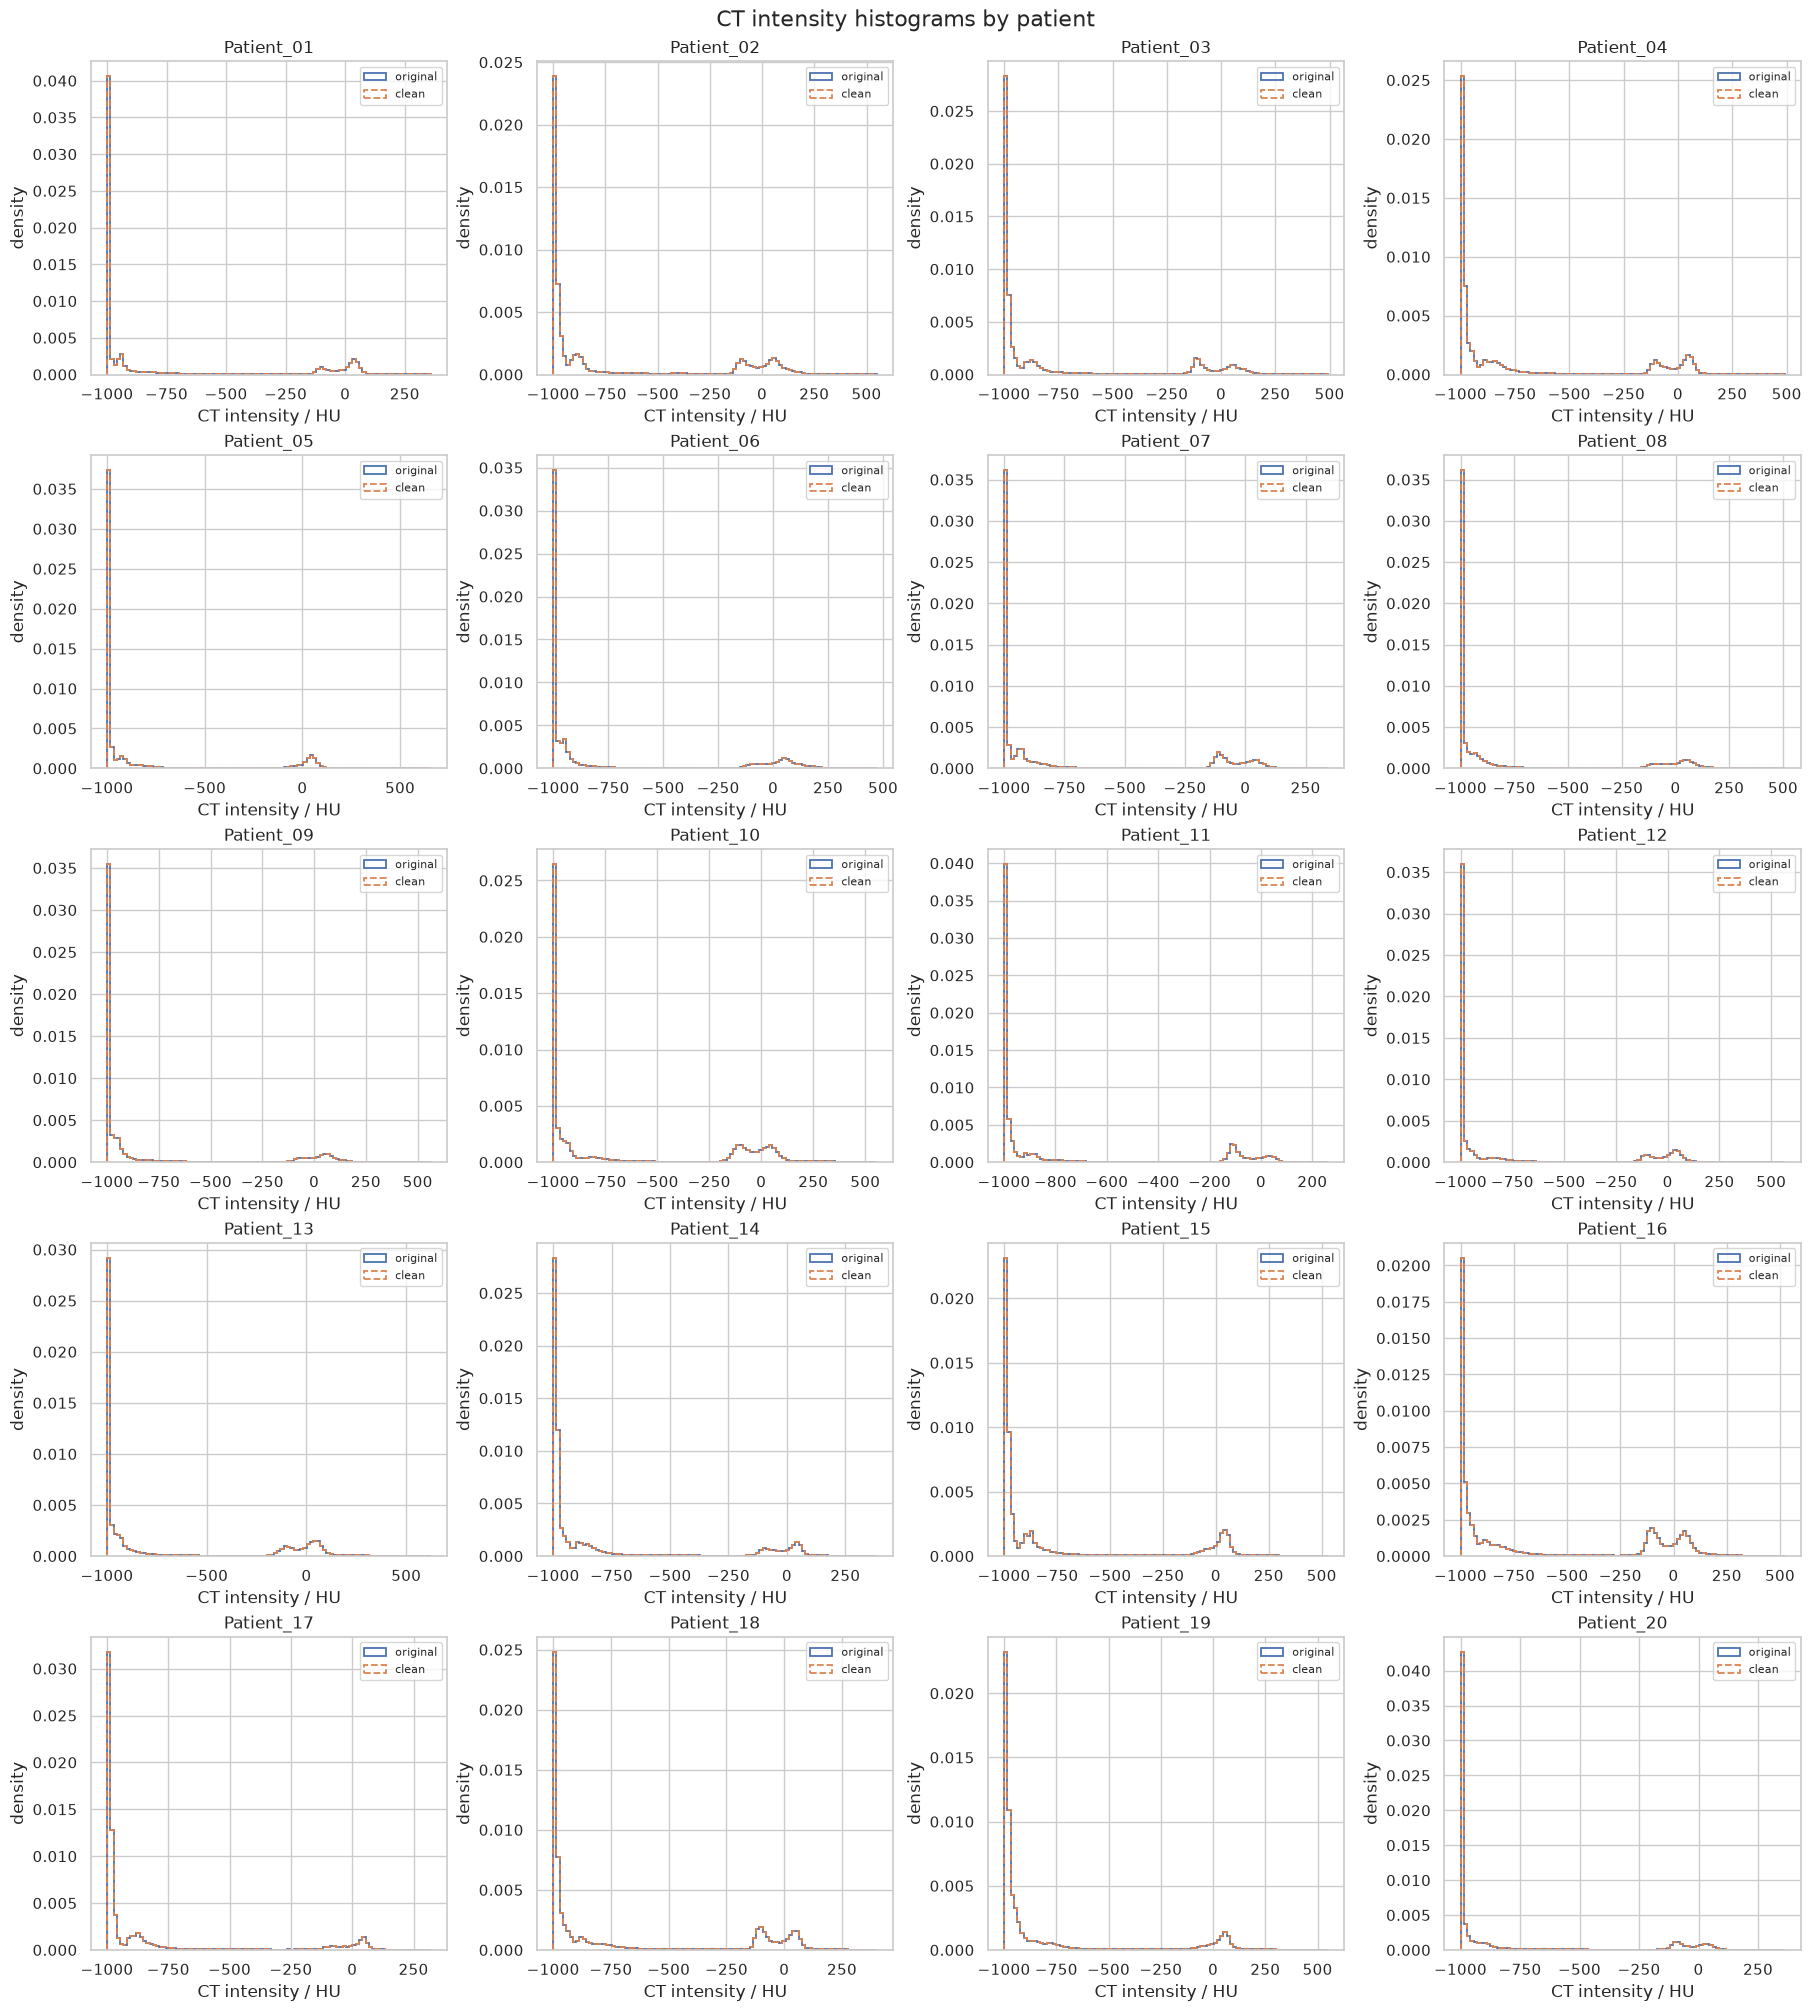

,p1,p5,p25,p50,p75,p95,p99
patient,,,,,,,
Patient_01,-1000.0,-1000.0,-1000.0,-994.0,-716.0,51.0,245.0
Patient_02,-1000.0,-1000.0,-1000.0,-965.0,-156.0,96.0,367.0
Patient_03,-1000.0,-1000.0,-1000.0,-978.0,-698.0,75.0,276.0
Patient_04,-1000.0,-1000.0,-1000.0,-967.0,-558.0,63.0,312.0
Patient_05,-1000.0,-1000.0,-1000.0,-996.0,-902.0,64.0,384.0
Patient_06,-1000.0,-1000.0,-1000.0,-989.0,-786.0,111.0,313.0
Patient_07,-1000.0,-1000.0,-1000.0,-984.0,-277.0,54.0,259.0
Patient_08,-1000.0,-1000.0,-1000.0,-993.0,-847.0,75.0,317.0
Patient_09,-1000.0,-1000.0,-1000.0,-994.0,-887.0,87.0,366.0


In [10]:
fig, axes = plt.subplots(5, 4, figsize=(18, 20), constrained_layout=True)

for ax, patient in zip(axes.flat, patients):
    _, _, original_ct, _ = load_patient(ORIGINAL_ROOT, patient)
    _, _, clean_ct, _ = load_patient(CLEAN_ROOT, patient)
    lower, upper = np.percentile(original_ct, [0.5, 99.5])
    bins = np.linspace(lower, upper, 100)
    ax.hist(original_ct.ravel(), bins=bins, density=True, histtype='step', linewidth=1.3, label='original')
    ax.hist(clean_ct.ravel(), bins=bins, density=True, histtype='step', linewidth=1.3, linestyle='--', label='clean')
    ax.set_title(patient)
    ax.set_xlabel('CT intensity / HU')
    ax.set_ylabel('density')
    ax.legend(fontsize=8)

fig.suptitle('CT intensity histograms by patient', fontsize=16)
plt.show()

percentile_columns = [f'original_p{p}' for p in PERCENTILES]
percentile_table = summary[percentile_columns].rename(columns=lambda name: name.replace('original_', ''))
display(percentile_table.round(1))

## CT minimum, maximum, and percentile ranges

,original_min,original_p1,original_p5,original_p50,original_p95,original_p99,original_max
patient,,,,,,,
Patient_01,-1000.0,-1000.0,-1000.0,-994.0,51.0,245.0,3071.0
Patient_02,-1000.0,-1000.0,-1000.0,-965.0,96.0,367.0,26613.0
Patient_03,-1000.0,-1000.0,-1000.0,-978.0,75.0,276.0,25292.0
Patient_04,-1000.0,-1000.0,-1000.0,-967.0,63.0,312.0,4551.0
Patient_05,-1000.0,-1000.0,-1000.0,-996.0,64.0,384.0,3071.0
Patient_06,-1000.0,-1000.0,-1000.0,-989.0,111.0,313.0,3071.0
Patient_07,-1000.0,-1000.0,-1000.0,-984.0,54.0,259.0,3059.0
Patient_08,-1000.0,-1000.0,-1000.0,-993.0,75.0,317.0,3071.0
Patient_09,-1000.0,-1000.0,-1000.0,-994.0,87.0,366.0,3071.0


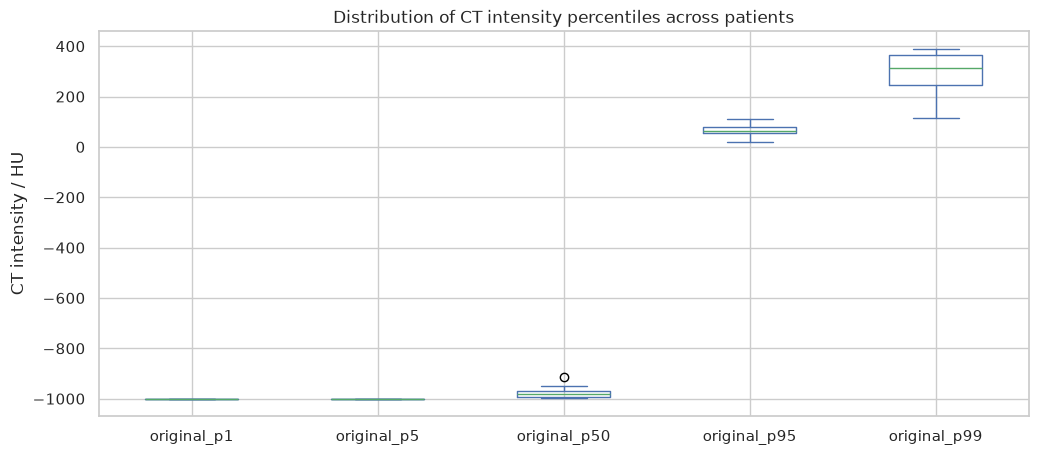

In [11]:
range_columns = ['original_min', 'original_p1', 'original_p5', 'original_p50', 'original_p95', 'original_p99', 'original_max']
display(summary[range_columns].round(1))
fig, ax = plt.subplots(figsize=(12, 5))
summary[['original_p1', 'original_p5', 'original_p50', 'original_p95', 'original_p99']].plot(kind='box', ax=ax)
ax.set_ylabel('CT intensity / HU')
ax.set_title('Distribution of CT intensity percentiles across patients')
plt.show()

## Voxel spacing and image dimensions

Spacing matters for physical organ volumes and for any future 3D metric.

,spacing_x_mm,spacing_y_mm,spacing_z_mm,shape_x,shape_y,shape_z,voxel_volume_mm3
patient,,,,,,,
Patient_01,0.977,0.977,2.0,512,512,229,1.907
Patient_02,0.977,0.977,2.5,512,512,246,2.384
Patient_03,0.977,0.977,2.5,512,512,147,2.384
Patient_04,0.977,0.977,2.5,512,512,158,2.384
Patient_05,0.977,0.977,2.0,512,512,284,1.907
Patient_06,0.977,0.977,2.5,512,512,199,2.384
Patient_07,0.977,0.977,2.0,512,512,179,1.907
Patient_08,0.977,0.977,2.5,512,512,171,2.384
Patient_09,0.977,0.977,2.5,512,512,154,2.384


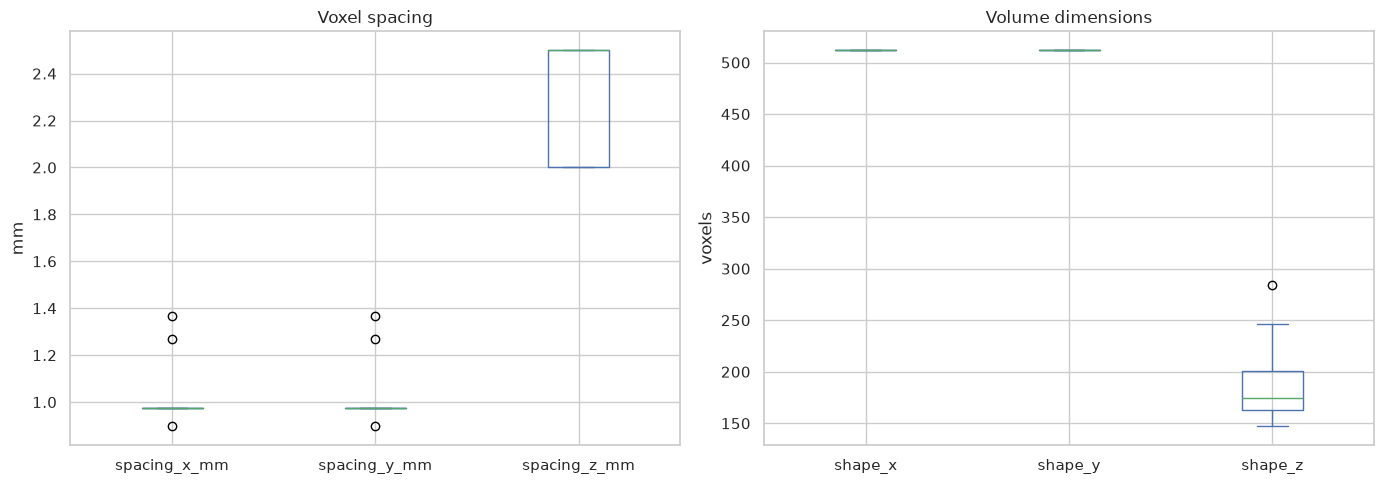

In [12]:
spacing_columns = ['spacing_x_mm', 'spacing_y_mm', 'spacing_z_mm']
display(summary[spacing_columns + ['shape_x', 'shape_y', 'shape_z', 'voxel_volume_mm3']].round(3))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
summary[spacing_columns].plot(kind='box', ax=axes[0])
axes[0].set_ylabel('mm')
axes[0].set_title('Voxel spacing')
summary[['shape_x', 'shape_y', 'shape_z']].plot(kind='box', ax=axes[1])
axes[1].set_ylabel('voxels')
axes[1].set_title('Volume dimensions')
plt.tight_layout()
plt.show()

## Original versus clean labels

The clean labels can differ because the preprocessing work repaired merged esophagus/aorta annotations and patient-specific label errors. The following tables quantify those changes without assuming that every clean label is automatically correct.

In [13]:
label_change_rows = []
for patient in patients:
    _, _, original_ct, original_gt = load_patient(ORIGINAL_ROOT, patient)
    _, _, clean_ct, clean_gt = load_patient(CLEAN_ROOT, patient)
    if original_gt.shape != clean_gt.shape:
        continue
    changed = original_gt != clean_gt
    row = {'patient': patient, 'changed_voxels': int(changed.sum()), 'changed_fraction': float(changed.mean())}
    for original_class, original_name in CLASS_NAMES.items():
        for clean_class, clean_name in CLASS_NAMES.items():
            row[f'{original_name}_to_{clean_name}'] = int(np.count_nonzero((original_gt == original_class) & (clean_gt == clean_class)))
    label_change_rows.append(row)

label_changes = pd.DataFrame(label_change_rows).set_index('patient')
display(label_changes[['changed_voxels', 'changed_fraction']].sort_values('changed_voxels', ascending=False))

transition_columns = [column for column in label_changes.columns if '_to_' in column and column.split('_to_')[0] != column.split('_to_')[1]]
transition_totals = label_changes[transition_columns].sum().sort_values(ascending=False)
display(transition_totals[transition_totals > 0].to_frame('voxels'))

,changed_voxels,changed_fraction
patient,,
Patient_15,232590,0.005915
Patient_04,149910,0.003619
Patient_12,149731,0.003340
Patient_05,136553,0.001834
Patient_13,133168,0.002228
Patient_06,119931,0.002299
Patient_10,108723,0.002544
Patient_01,106553,0.001775
Patient_18,97057,0.002023


,voxels
esophagus_to_aorta,1953561


## Organ volumes

Volumes are calculated from label voxel counts multiplied by the NIfTI voxel volume. The clean dataset is plotted beside the original so repaired-label effects are visible.

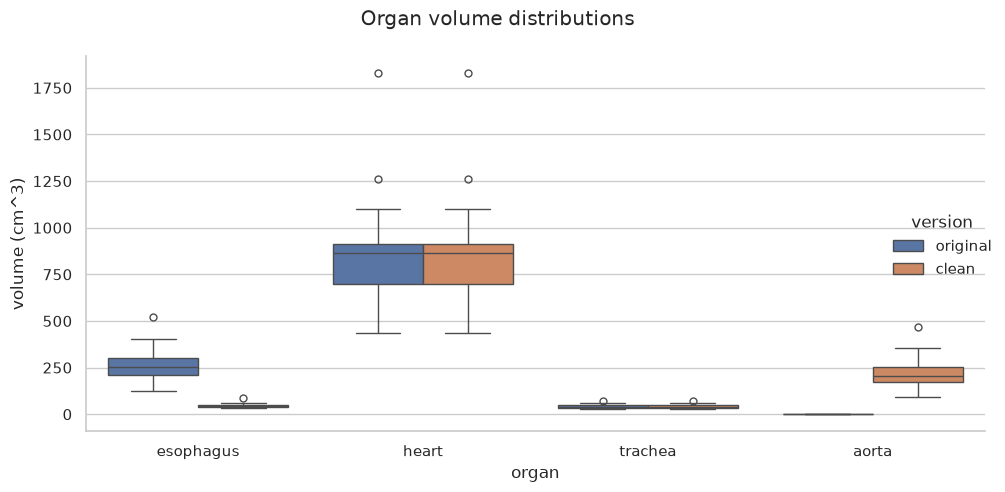

median    mean     std     min      max
version  class                                             
clean    aorta      203.10  219.92   83.62   94.77   467.32
         esophagus   45.32   46.94   12.31   31.26    86.86
         heart      862.05  869.35  298.35  437.99  1829.26
         trachea     38.77   41.55   11.81   27.59    72.92
original aorta        0.00    0.00    0.00    0.00     0.00
         esophagus  255.72  266.86   87.31  126.97   522.25
         heart      862.05  869.35  298.35  437.99  1829.26
         trachea     38.77   41.55   11.81   27.59    72.92

In [14]:
volume_rows = []
for patient in patients:
    for version, root in [('original', ORIGINAL_ROOT), ('clean', CLEAN_ROOT)]:
        ct_img, _, _, gt = load_patient(root, patient)
        voxel_volume_cm3 = float(np.prod(ct_img.header.get_zooms()[:3]) / 1000)
        for class_id, class_name in CLASS_NAMES.items():
            volume_rows.append({'patient': patient, 'version': version, 'class': class_name,
                                'voxels': int((gt == class_id).sum()),
                                'volume_cm3': float((gt == class_id).sum() * voxel_volume_cm3)})

volumes = pd.DataFrame(volume_rows)
foreground_volumes = volumes[volumes['class'] != 'background']
g = sns.catplot(data=foreground_volumes, x='class', y='volume_cm3', hue='version', kind='box', height=5, aspect=1.8)
g.set_axis_labels('organ', 'volume (cm^3)')
g.figure.suptitle('Organ volume distributions')
g.figure.tight_layout()
plt.show()

display(foreground_volumes.groupby(['version', 'class'])['volume_cm3'].agg(['median', 'mean', 'std', 'min', 'max']).round(2))

## Class imbalance

Class imbalance is shown both as total voxel share and as per-patient share. Background is included because it dominates the training loss, while foreground-only views make organ imbalance easier to interpret.

,class,voxels,fraction
1,background,968101701,0.98955
3,heart,7496021,0.00766
0,aorta,1953561,0.00200
2,esophagus,404352,0.00041
4,trachea,365773,0.00037


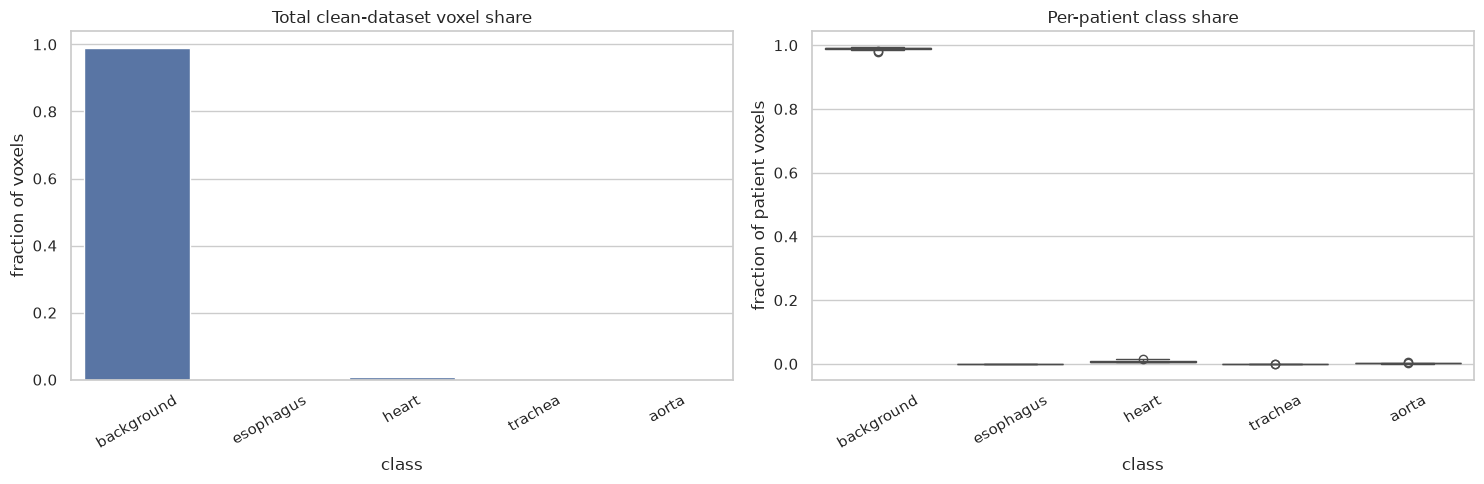

In [10]:
imbalance_rows = []
for patient in patients:
    _, _, _, gt = load_patient(CLEAN_ROOT, patient)
    total = gt.size
    for class_id, class_name in CLASS_NAMES.items():
        count = int((gt == class_id).sum())
        imbalance_rows.append({'patient': patient, 'class': class_name, 'voxels': count, 'fraction': count / total})

imbalance = pd.DataFrame(imbalance_rows)
class_totals = imbalance.groupby('class', as_index=False)['voxels'].sum()
class_totals['fraction'] = class_totals['voxels'] / class_totals['voxels'].sum()
display(class_totals.sort_values('fraction', ascending=False).round(5))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=class_totals, x='class', y='fraction', ax=axes[0], order=list(CLASS_NAMES.values()))
axes[0].set_title('Total clean-dataset voxel share')
axes[0].set_ylabel('fraction of voxels')
axes[0].tick_params(axis='x', rotation=30)
sns.boxplot(data=imbalance, x='class', y='fraction', ax=axes[1], order=list(CLASS_NAMES.values()))
axes[1].set_title('Per-patient class share')
axes[1].set_ylabel('fraction of patient voxels')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

,class,voxels,foreground_fraction,foreground_percentage
3,heart,7496021,0.73349,73.35
0,aorta,1953561,0.19116,19.12
2,esophagus,404352,0.03957,3.96
4,trachea,365773,0.03579,3.58


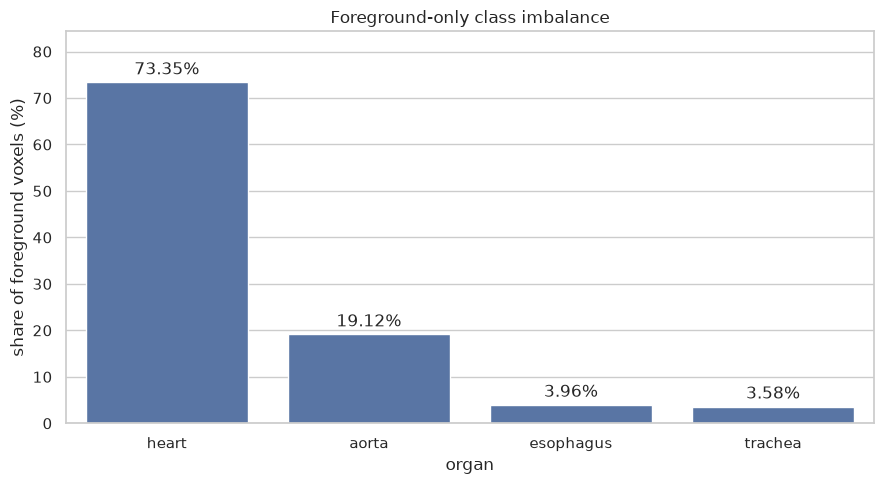

In [11]:
# Foreground-only class imbalance: exclude background from the denominator
foreground_totals = class_totals[class_totals['class'] != 'background'].copy()
foreground_total_voxels = foreground_totals['voxels'].sum()
foreground_totals['foreground_fraction'] = (
    foreground_totals['voxels'] / foreground_total_voxels
)
foreground_totals['foreground_percentage'] = 100 * foreground_totals['foreground_fraction']

# Display the values numerically so small organ shares remain visible.
display(
    foreground_totals[['class', 'voxels', 'foreground_fraction', 'foreground_percentage']]
    .sort_values('foreground_fraction', ascending=False)
    .round({'foreground_fraction': 5, 'foreground_percentage': 2})
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    data=foreground_totals,
    x='class',
    y='foreground_percentage',
    order=['heart', 'aorta', 'esophagus', 'trachea'],
    ax=ax,
)
ax.set_title('Foreground-only class imbalance')
ax.set_xlabel('organ')
ax.set_ylabel('share of foreground voxels (%)')
ax.set_ylim(0, foreground_totals['foreground_percentage'].max() * 1.15)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', padding=3)
plt.tight_layout()
plt.show()

,patient,class,voxels,foreground_fraction,foreground_percentage
2,Patient_01,heart,365637,0.6814,68.14
4,Patient_01,aorta,106553,0.1986,19.86
1,Patient_01,esophagus,32375,0.0603,6.03
3,Patient_01,trachea,32009,0.0597,5.97
7,Patient_02,heart,359613,0.7504,75.04
...,...,...,...,...,...
91,Patient_19,esophagus,16185,0.0346,3.46
97,Patient_20,heart,269845,0.8152,81.52
99,Patient_20,aorta,43432,0.1312,13.12
96,Patient_20,esophagus,10518,0.0318,3.18


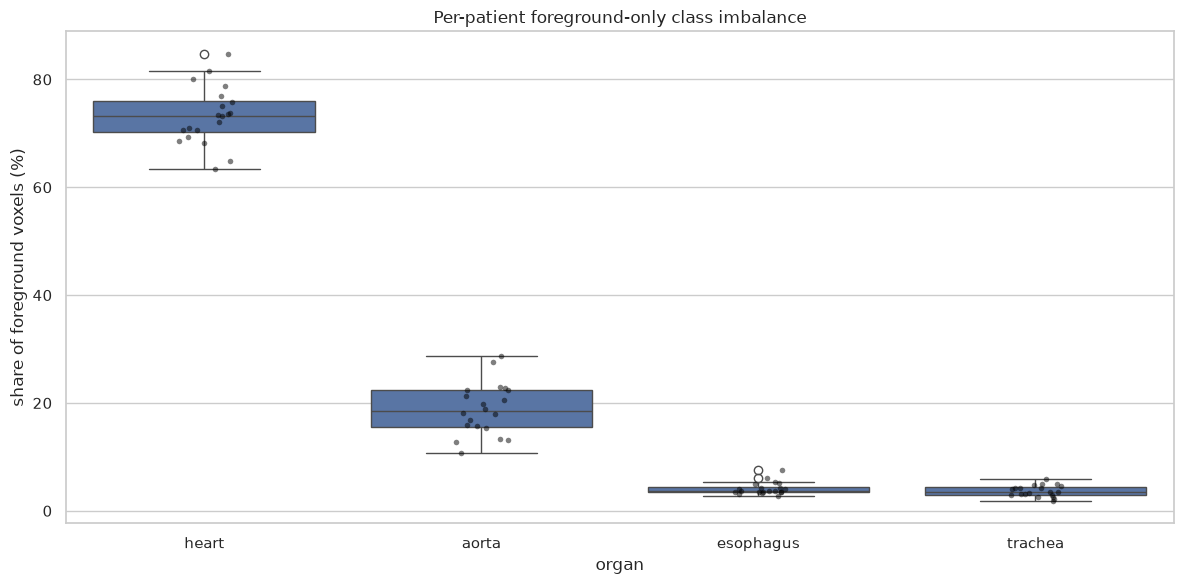

In [12]:
# Per-patient foreground-only class shares
foreground_imbalance = imbalance[imbalance['class'] != 'background'].copy()

foreground_totals_per_patient = (
    foreground_imbalance
    .groupby('patient')['voxels']
    .transform('sum')
)

foreground_imbalance['foreground_fraction'] = (
    foreground_imbalance['voxels'] / foreground_totals_per_patient
)

foreground_imbalance['foreground_percentage'] = (
    100 * foreground_imbalance['foreground_fraction']
)

display(
    foreground_imbalance[
        ['patient', 'class', 'voxels',
         'foreground_fraction', 'foreground_percentage']
    ]
    .sort_values(['patient', 'foreground_fraction'], ascending=[True, False])
    .round({
        'foreground_fraction': 4,
        'foreground_percentage': 2
    })
)

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=foreground_imbalance,
    x='class',
    y='foreground_percentage',
    order=['heart', 'aorta', 'esophagus', 'trachea']
)

sns.stripplot(
    data=foreground_imbalance,
    x='class',
    y='foreground_percentage',
    order=['heart', 'aorta', 'esophagus', 'trachea'],
    color='black',
    alpha=0.5,
    size=4
)

plt.title('Per-patient foreground-only class imbalance')
plt.xlabel('organ')
plt.ylabel('share of foreground voxels (%)')
plt.tight_layout()
plt.show()

## Scatterplots

### Scan Size vs Organ Volume

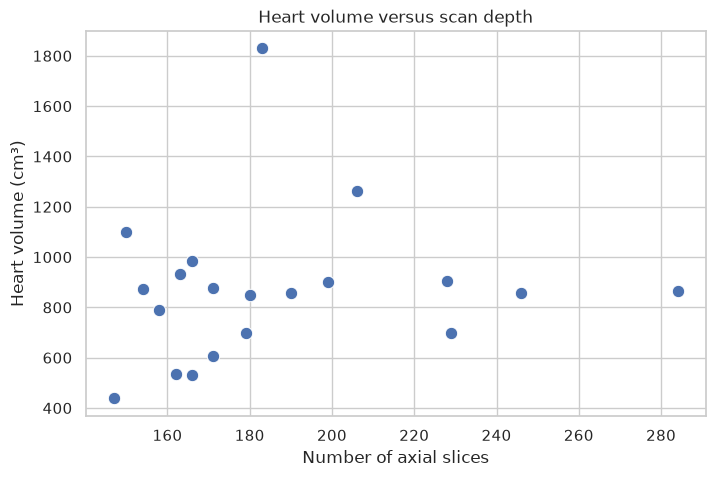

In [13]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=summary,
    x='shape_z',
    y='clean_heart_volume_cm3',
    s=80
)

plt.xlabel('Number of axial slices')
plt.ylabel('Heart volume (cm³)')
plt.title('Heart volume versus scan depth')
plt.show()

### Organ Volume versus voxel spacing

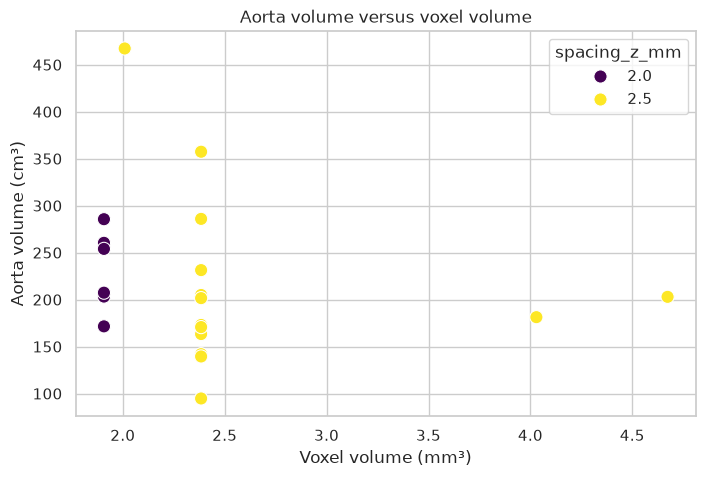

In [14]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=summary,
    x='voxel_volume_mm3',
    y='clean_aorta_volume_cm3',
    hue='spacing_z_mm',
    palette='viridis',
    s=90
)

plt.xlabel('Voxel volume (mm³)')
plt.ylabel('Aorta volume (cm³)')
plt.title('Aorta volume versus voxel volume')
plt.show()

### CT intensity percentiles

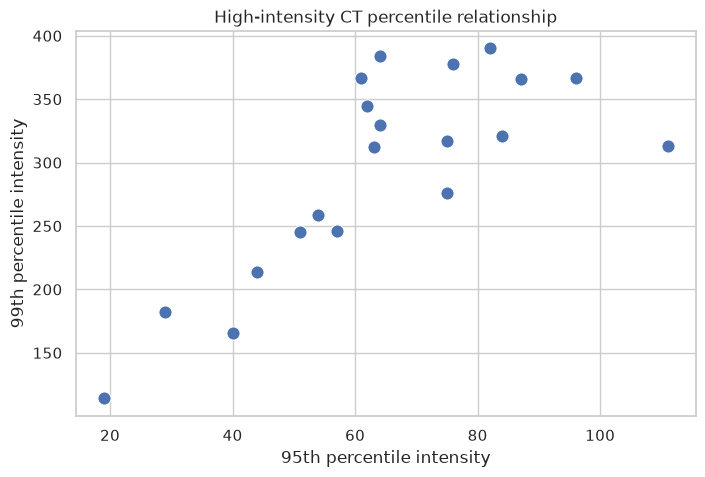

In [16]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=summary,
    x='original_p95',
    y='original_p99',
    s=90
)

plt.xlabel('95th percentile intensity')
plt.ylabel('99th percentile intensity')
plt.title('High-intensity CT percentile relationship')
plt.show()

### CT range versus scan depth

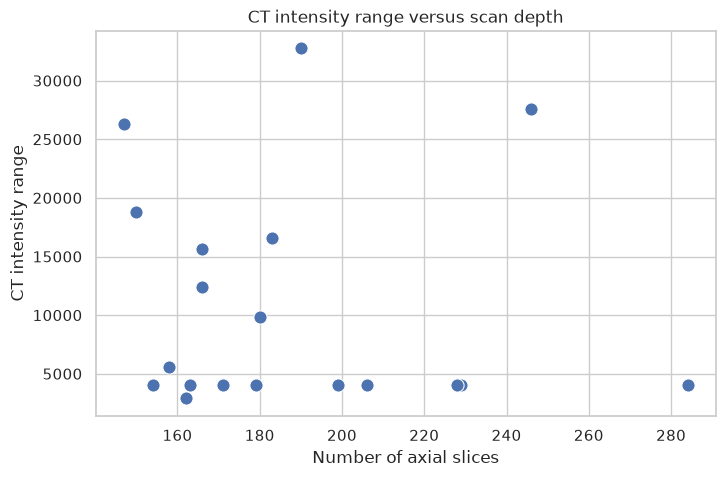

In [17]:
summary = summary.copy()
summary['intensity_range'] = (
    summary['original_max'] - summary['original_min']
)

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=summary,
    x='shape_z',
    y='intensity_range',
    s=90
)

plt.xlabel('Number of axial slices')
plt.ylabel('CT intensity range')
plt.title('CT intensity range versus scan depth')
plt.show()

### Foreground class share relationships

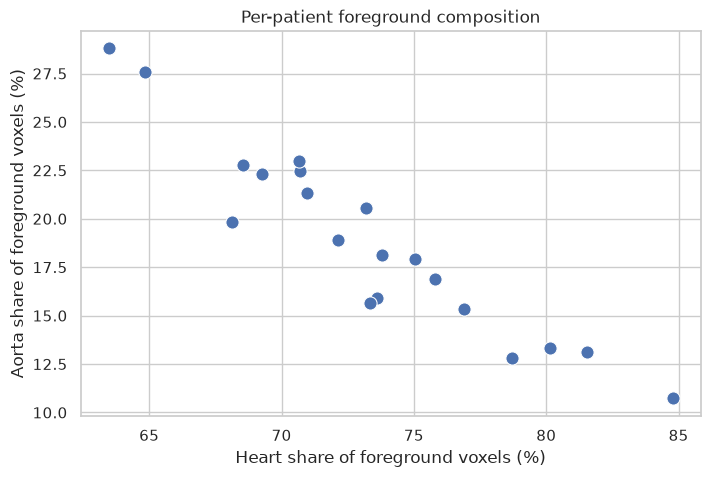

In [18]:
foreground_share_table = (
    foreground_imbalance
    .pivot(index='patient', columns='class', values='foreground_percentage')
    .reset_index()
)

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=foreground_share_table,
    x='heart',
    y='aorta',
    s=90
)

plt.xlabel('Heart share of foreground voxels (%)')
plt.ylabel('Aorta share of foreground voxels (%)')
plt.title('Per-patient foreground composition')
plt.show()

## Now looking at all 4 organs
### scan depth versus organ volume

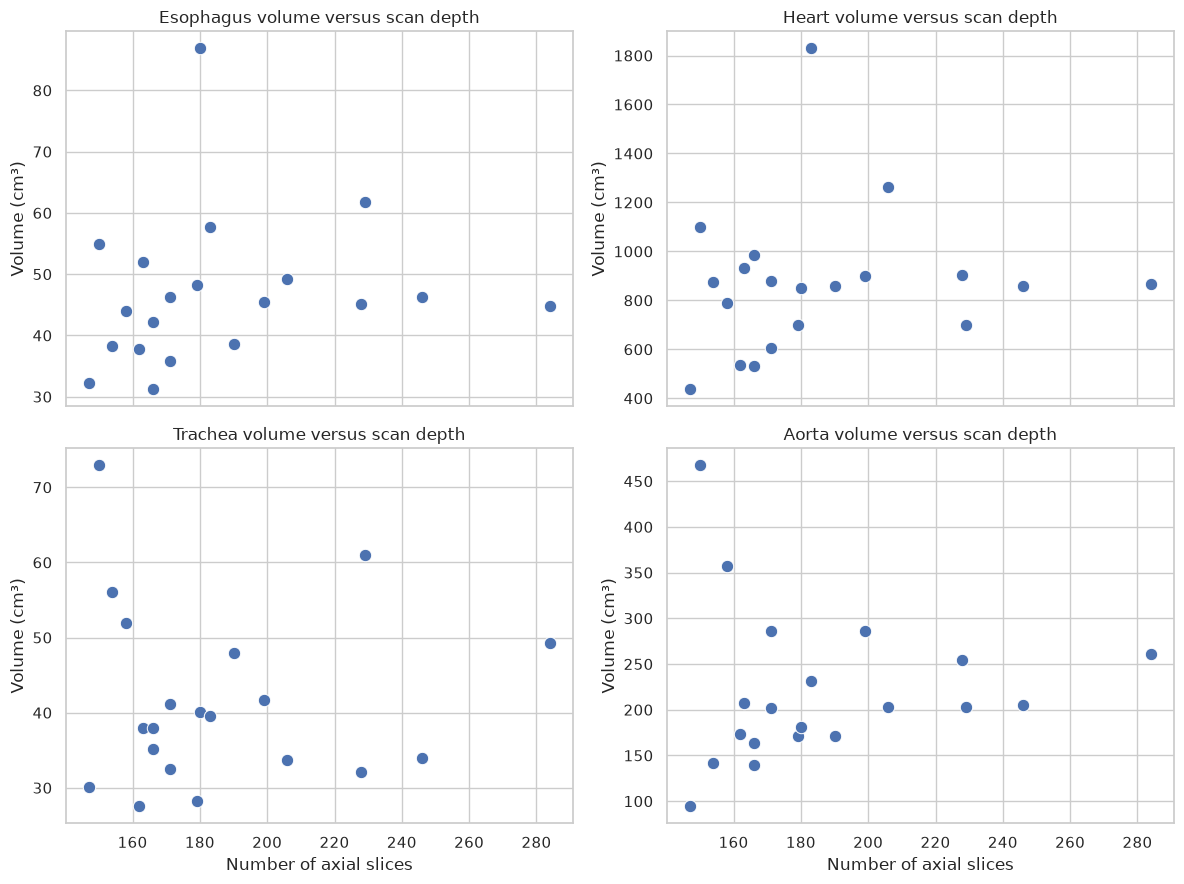

In [19]:
organ_volume_columns = {
    'Esophagus': 'clean_esophagus_volume_cm3',
    'Heart': 'clean_heart_volume_cm3',
    'Trachea': 'clean_trachea_volume_cm3',
    'Aorta': 'clean_aorta_volume_cm3',
}

fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True)

for ax, (organ, column) in zip(axes.flat, organ_volume_columns.items()):
    sns.scatterplot(
        data=summary,
        x='shape_z',
        y=column,
        s=80,
        ax=ax
    )
    ax.set_title(f'{organ} volume versus scan depth')
    ax.set_xlabel('Number of axial slices')
    ax.set_ylabel('Volume (cm³)')

plt.tight_layout()
plt.show()

### voxel volume versus organ volume

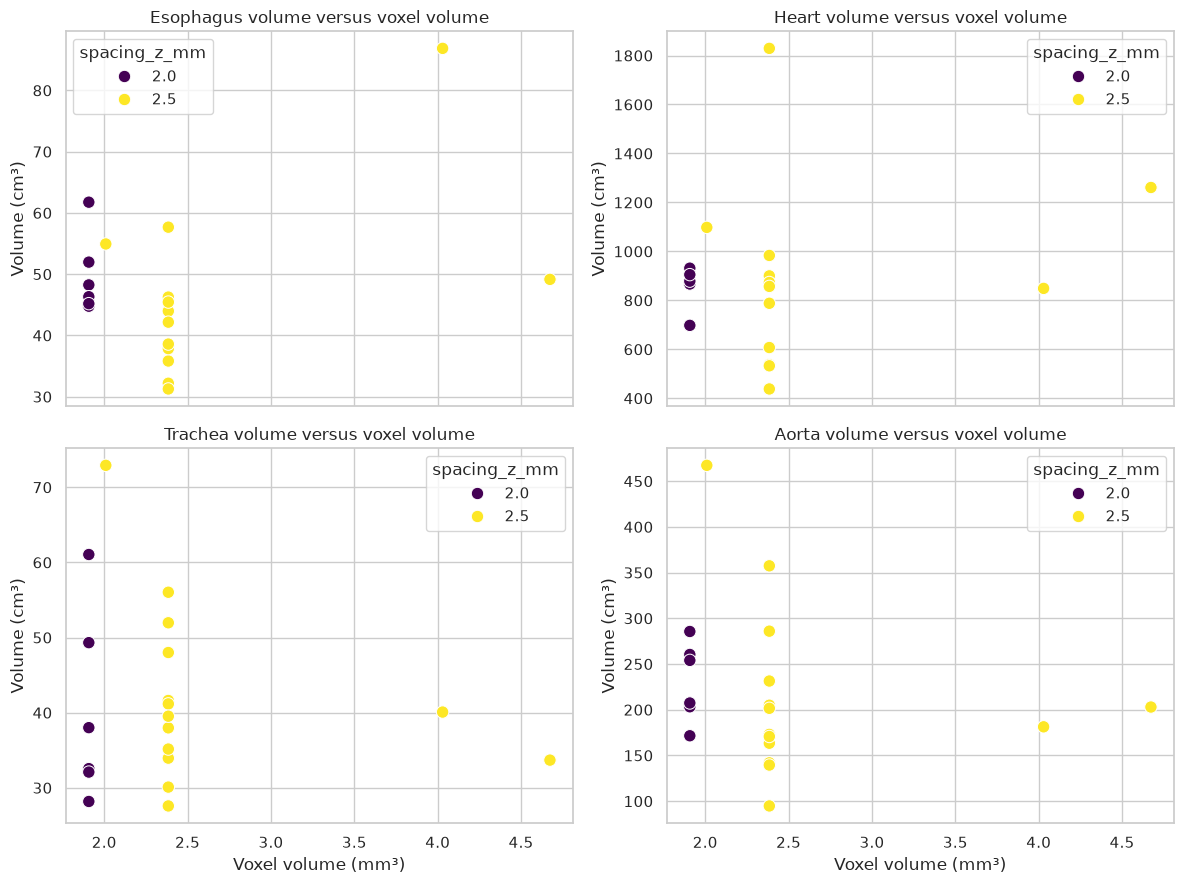

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True)

for ax, (organ, column) in zip(axes.flat, organ_volume_columns.items()):
    sns.scatterplot(
        data=summary,
        x='voxel_volume_mm3',
        y=column,
        hue='spacing_z_mm',
        palette='viridis',
        s=80,
        ax=ax
    )
    ax.set_title(f'{organ} volume versus voxel volume')
    ax.set_xlabel('Voxel volume (mm³)')
    ax.set_ylabel('Volume (cm³)')

plt.tight_layout()
plt.show()

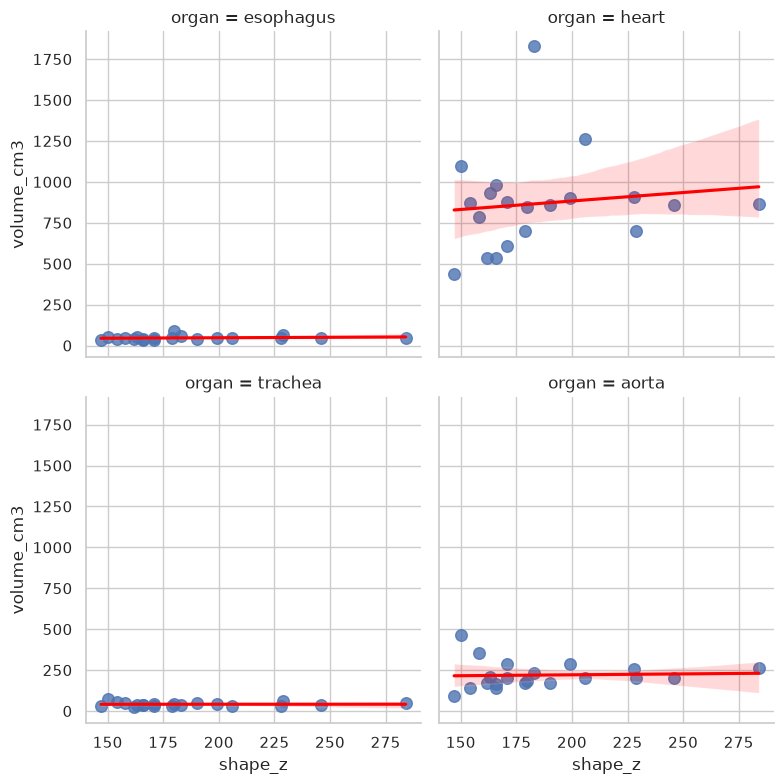

In [21]:
organ_volume_data = summary[
    ['shape_z'] + list(organ_volume_columns.values())
].melt(
    id_vars='shape_z',
    var_name='organ',
    value_name='volume_cm3'
)

organ_volume_data['organ'] = organ_volume_data['organ'].str.replace(
    'clean_', ''
).str.replace(
    '_volume_cm3', ''
)

sns.lmplot(
    data=organ_volume_data,
    x='shape_z',
    y='volume_cm3',
    col='organ',
    col_wrap=2,
    height=4,
    scatter_kws={'s': 70},
    line_kws={'color': 'red'}
)

plt.show()